## Homework 2 (SVD)

### Downloading and visualization data

Original shape of img_1 (./svd-img-1.jpg): (1009, 1800, 3)
Original shape of img_2 (./svd-img-2.jpg): (2000, 2000, 3)


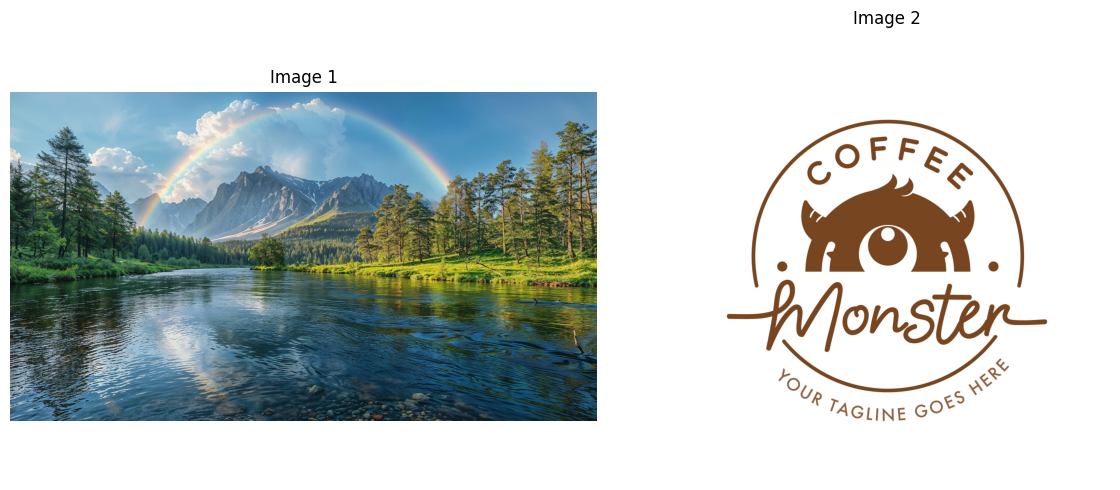

In [ ]:
from matplotlib.image import imread
import matplotlib.pyplot as plt

#  Define imgs paths
images_paths = ["./svd-img-1.jpg", "./svd-img-2.jpg"]
images = []

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, img in enumerate(images_paths):
    # Load image and save to the list
    image = imread(img)
    images.append(image)
    
    # Log shapes
    print(f"Original shape of img_{idx+1} ({img}): {image.shape}")
    
    # Plot image
    axes[idx].imshow(image, cmap='gray')
    axes[idx].axis('off')
    axes[idx].set_title(f"Image {idx + 1}")

plt.tight_layout()
plt.show()

### Reshape data to 2D-matrix, SVD and visualize Sigma matrix.

Shape of S(img_1): (1009,)
Shape of S(img_2): (2000,)


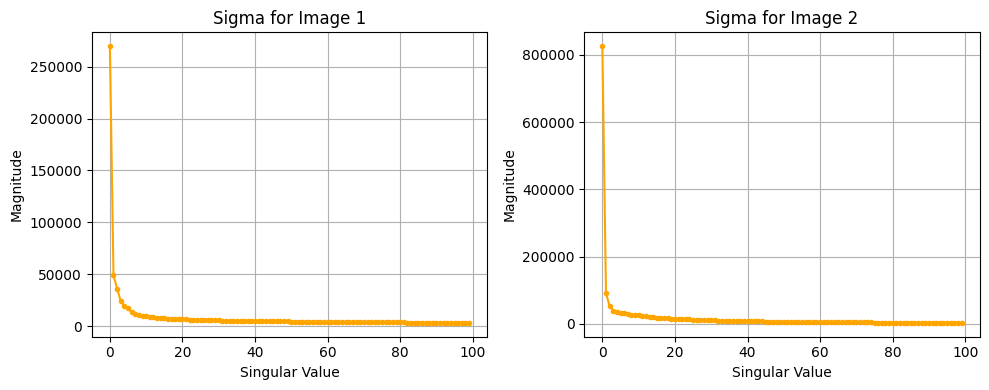

In [31]:
import numpy as np

flat_imgs = []
svd_res = []

for idx, img in enumerate(images):
    # reshape
    height, width, channels = img.shape
    flat_img = img.reshape(-1, width * channels)
    # save 
    flat_imgs.append(flat_img)
    
    # SVD
    U, S, Vt = np.linalg.svd(flat_img)
    svd_res.append(S)
    print(f"Shape of S(img_{idx + 1}): {S.shape}")

# Plot results
k = 100 # 

plt.figure(figsize=(10, 4))

for i, S in enumerate(svd_res):
    plt.subplot(1, 2, i+1)
    
    # The first k singular values
    plt.plot(np.arange(k), S[:k], marker='o', markersize=3, linestyle='-', color='orange')
    
    plt.title(f"Sigma for Image {i+1}")
    plt.xlabel("Singular Value")
    plt.ylabel("Magnitude")
    plt.grid(True)

plt.tight_layout()
plt.show()    

### TruncatedSVD, reconstruction and comparing with origins.

Image 1 -> MSE for k=100: 303.59
Image 2 -> MSE for k=100: 61.83


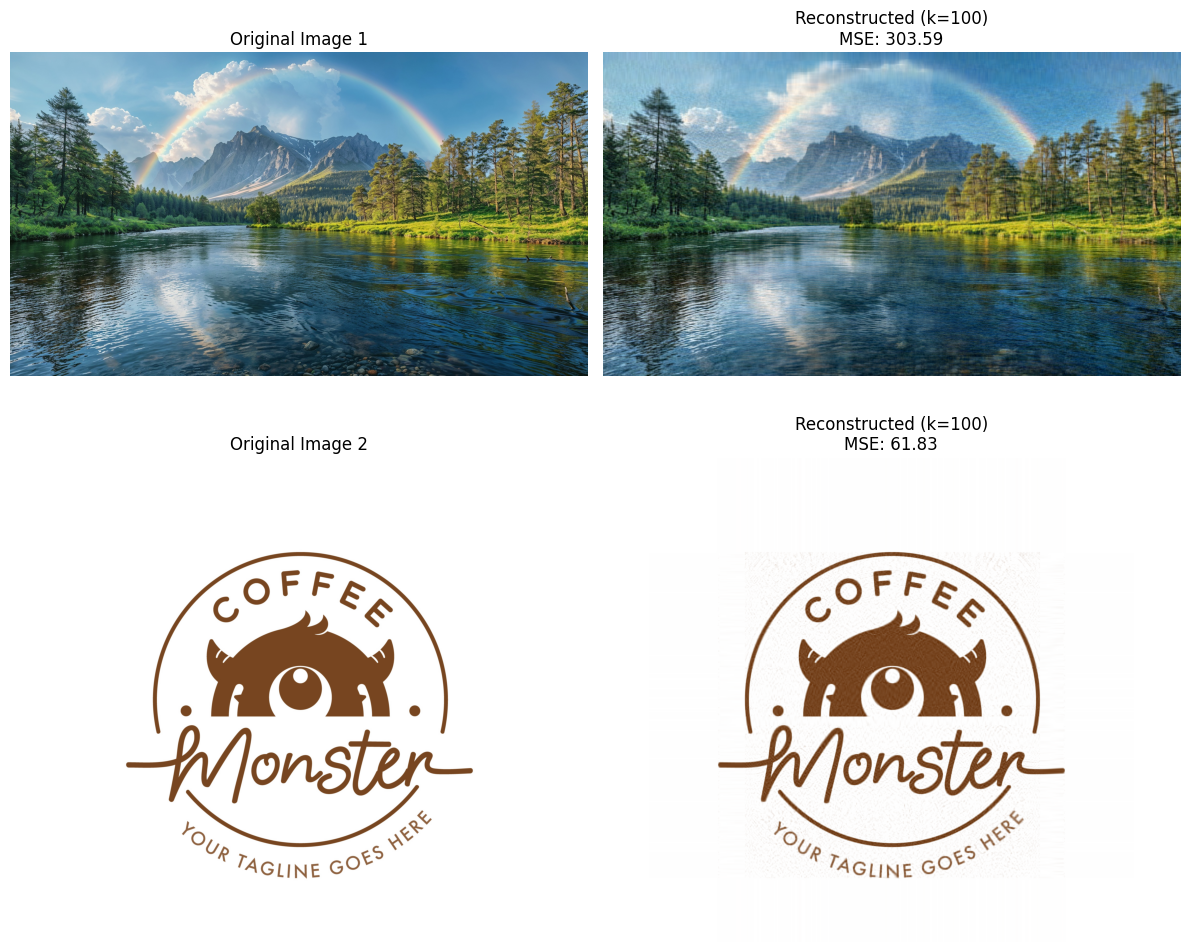

In [32]:
from sklearn.decomposition import TruncatedSVD
import numpy as np
import matplotlib.pyplot as plt

k = 100

# Original VS Reconstructed
fig, axes = plt.subplots(2, 2, figsize=(12, 5 * 2))

for i, (orig_img, flat_img) in enumerate(zip(images, flat_imgs)):
    # Original shape
    height, width, channels = orig_img.shape
    
    # TruncatedSVD
    svd = TruncatedSVD(n_components=k)
    truncated_image = svd.fit_transform(flat_img)
    
    # Reconstruct the flat img
    reconstructed_flat = svd.inverse_transform(truncated_image)
    
    # MSE
    reconstruction_error = np.mean(np.square(reconstructed_flat - flat_img))
    print(f"Image {i+1} -> MSE for k={k}: {reconstruction_error:.2f}")
    
    # Back to 3D
    reconstructed_img = reconstructed_flat.reshape(height, width, channels)
    reconstructed_img = np.clip(reconstructed_img, 0, 255).astype('uint8')
    
    # Plot Original Image
    axes[i][0].imshow(orig_img)
    axes[i][0].set_title(f"Original Image {i+1}")
    axes[i][0].axis('off')
    
    # Plot Reconstructed Image
    axes[i][1].imshow(reconstructed_img)
    axes[i][1].set_title(f"Reconstructed (k={k})\nMSE: {reconstruction_error:.2f}")
    axes[i][1].axis('off')

plt.tight_layout()
plt.show()

### K experiments

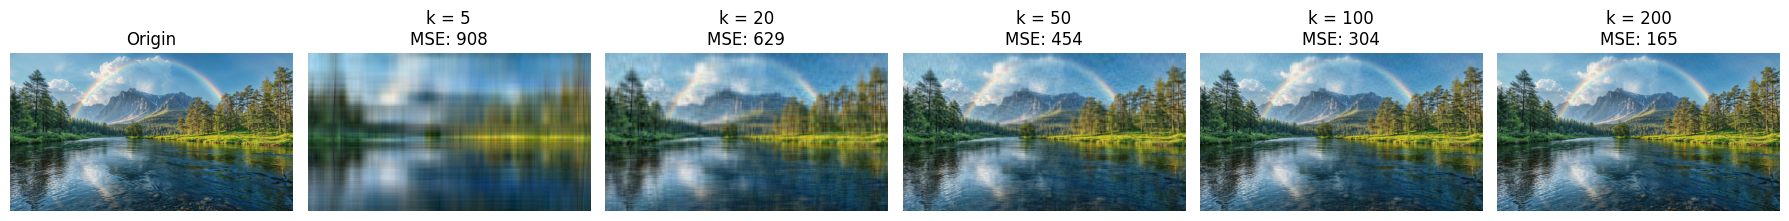

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

k_values = [5, 20, 50, 100, 200]

# Image 1
orig_img = images[0]
flat_img = flat_imgs[0]
height, width, channels = orig_img.shape

fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(18, 4))

# Plot origin
axes[0].imshow(orig_img)
axes[0].set_title("Origin")
axes[0].axis('off')

for idx, k in enumerate(k_values):
    svd = TruncatedSVD(n_components=k)
    truncated_image = svd.fit_transform(flat_img)
    
    # Reconstruct the image
    reconstructed_flat = svd.inverse_transform(truncated_image)
    
    # MSE
    mse = np.mean(np.square(reconstructed_flat - flat_img))
    
    # Reshape to 3D
    reconstructed_img = reconstructed_flat.reshape(height, width, channels)
    reconstructed_img = np.clip(reconstructed_img, 0, 255).astype('uint8')
    
    ax = axes[idx + 1]
    ax.imshow(reconstructed_img)
    
    ax.set_title(f"k = {k}\nMSE: {mse:.0f}")
    ax.axis('off')

plt.tight_layout()
plt.show()

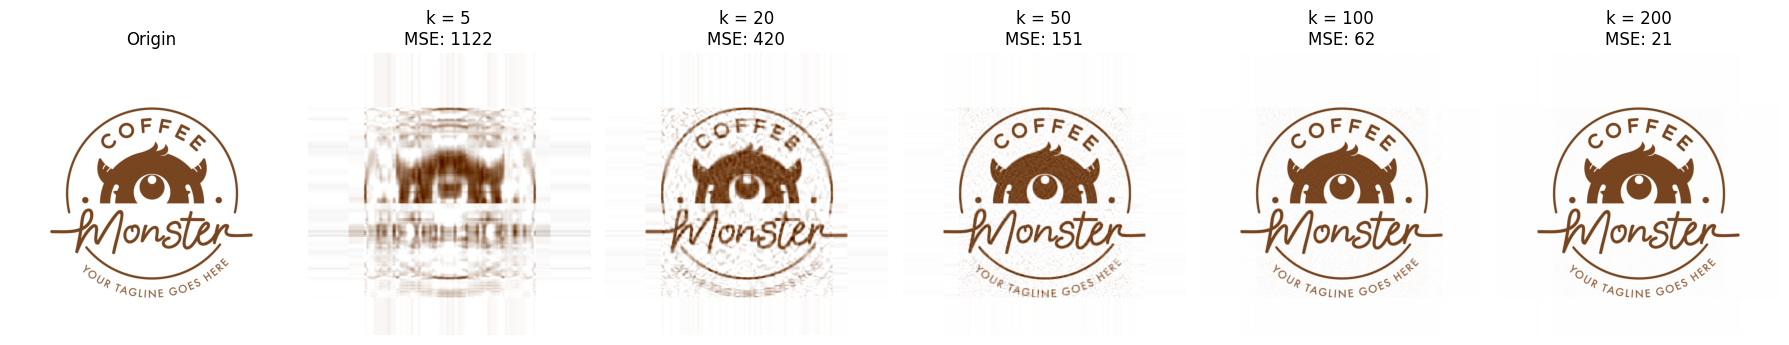

In [34]:
# Image 2
orig_img = images[1]
flat_img = flat_imgs[1]
height, width, channels = orig_img.shape

fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(18, 4))

# Plot origin
axes[0].imshow(orig_img)
axes[0].set_title("Origin")
axes[0].axis('off')

for idx, k in enumerate(k_values):
    svd = TruncatedSVD(n_components=k)
    truncated_image = svd.fit_transform(flat_img)
    
    # Reconstruct the image
    reconstructed_flat = svd.inverse_transform(truncated_image)
    
    # MSE
    mse = np.mean(np.square(reconstructed_flat - flat_img))
    
    # Reshape to 3D
    reconstructed_img = reconstructed_flat.reshape(height, width, channels)
    reconstructed_img = np.clip(reconstructed_img, 0, 255).astype('uint8')
    
    ax = axes[idx + 1]
    ax.imshow(reconstructed_img)
    
    ax.set_title(f"k = {k}\nMSE: {mse:.0f}")
    ax.axis('off')

plt.tight_layout()
plt.show()

### Conslusion

- `k=5`: a blurry  image. MSE is huge. Here the $\Sigma$ matrix contains too little information for high-quality restoration. 
- `k=20` : The main shapes and colors appear, but details (such as text or small textures) are not enough readable. 
- `k=50` : It's already quite enough to see the pic and read the text although not high quality.
- `k=100-200` : The image becomes visually identical to the original. These are the points of effective compression. 